# Runtime

##### Updated 11/2024

#### Local
* should work with same python3 environment as parse_projects.py 

#### Colab:
* run `./ableton_projects/start_notebook.sh` to start
server on `8888`
* see `start_notebook.sh` for installing python2 kernel and packages
* see https://research.google.com/colaboratory/local-runtimes.html


# Modules

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

import sys
print('Python Version: %s' % sys.version)

import parse_projects as parse_lib


Python Version: 3.12.6 (tags/v3.12.6:a4a2d2b, Sep  6 2024, 20:11:23) [MSC v.1940 64 bit (AMD64)]


In [6]:
#@title Get info for all Projects and cache

# Load projects using default args should work if notebook is in project dir.
project_dir = "./" #@param {type:"string"}
# SKIP_FOLDERS = [ 'Backup', 'old', 'Samples', 'Ableton Project Info', '.git'] #@param {type:"raw"}
# CACHE_DIR = "./logs/" #@param {type:"string"}
load_most_recent_cached = True #@param {type:"boolean"}


# Load from recent cache (fast)
if load_most_recent_cached: 
  project_errors = {}
  project_info = parse_lib.load_info(prefix=parse_lib.CACHE_INFO_FILE, load_most_recent=True)
  project_errors = parse_lib.load_info(prefix=parse_lib.CACHE_ERROR_FILE, load_most_recent=True)

# Parse project .als files
else:
  project_info, project_errors = parse_lib.run_parser(project_dir)



Loading project_info from 2024-11-28 23:30:01.
Loaded 466 project_info in 0.01 seconds.
Loading project_errors from 2024-11-28 23:30:01.
Loaded 6 project_errors in 0.00 seconds.


# Analysis

In [8]:
#@title Get plugins from all projects

def query_projects_by_plugin(project_info, plugin_type, preset_name):
  project_keys = []
  assert plugin_type in ['PluginDevice', 'AuPluginDevice']
  for fname, v in project_info.items():
    for track in v['tracks']:
      for dev in track['devices']:
        if dev['type'] == plugin_type and dev['preset'] == preset_name:
            project_keys.append('%s-%d' % (fname, track['index']))

  return project_keys

def get_plugin_usage(project_info):
  plugins = {'vst': [], 'audio_unit': [], 'ableton': []}
  for fname, v in project_info.items():
    for track in v['tracks']:
      for dev in track['devices']:
        if dev['type'] == 'PluginDevice': # for vsts
          plugins['vst'].append(dev['preset'])
        elif dev['type'] == 'AuPluginDevice':  # for audiounits
          plugins['audio_unit'].append(dev['preset'])
        else:  # for default ableton plugin
          plugins['ableton'].append(dev['type'])
  plugins_usage = {k:pd.value_counts(pd.Series(v)) for k,v in plugins.items()}
  return plugins_usage

# # TEST
# plugins = get_plugin_usage(project_info)
# pprint(plugins)

# query_projects_by_plugin(project_info,
#     plugin_type='PluginDevice',
#     preset_name='Maschine 2'
# )

C:\Users\jake\AppData\Local\Temp\ipykernel_26240\3528766080.py:25: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  plugins_usage = {k:pd.value_counts(pd.Series(v)) for k,v in plugins.items()}
C:\Users\jake\AppData\Local\Temp\ipykernel_26240\3528766080.py:25: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  plugins_usage = {k:pd.value_counts(pd.Series(v)) for k,v in plugins.items()}
C:\Users\jake\AppData\Local\Temp\ipykernel_26240\3528766080.py:25: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  plugins_usage = {k:pd.value_counts(pd.Series(v)) for k,v in plugins.items()}


1000 least used vst plugins:
Guitar Rig 5                 396
iZotope Ozone 5              189
Maschine 2                   181
Komplete Kontrol             143
Solid Bus Comp                44
Reaktor 6 FX                  42
Ozone Pro                     30
Toraverb                      28
TAL-Chorus-LX                 23
Dirt                          18
iZotope Alloy 2               17
Tal-Chorus-LX                 16
Guitar Rig 6                  15
GS-201                        10
iZotope Stutter Edit           9
ValhallaRoom                   8
AmpliTube 4                    8
iZotope Ozone 5 Reverb         7
iZotope Ozone 5 Imager         6
Zebra2                         6
Driver                         5
Drumazon                       5
Microtonic                     4
iZotope Nectar 2               4
iZotope Ozone 5 Equalizer      3
TAL-U-No-62                    3
iZotope Insight                3
MonoPoly                       3
Phoscyon                       3
Neutron 3     

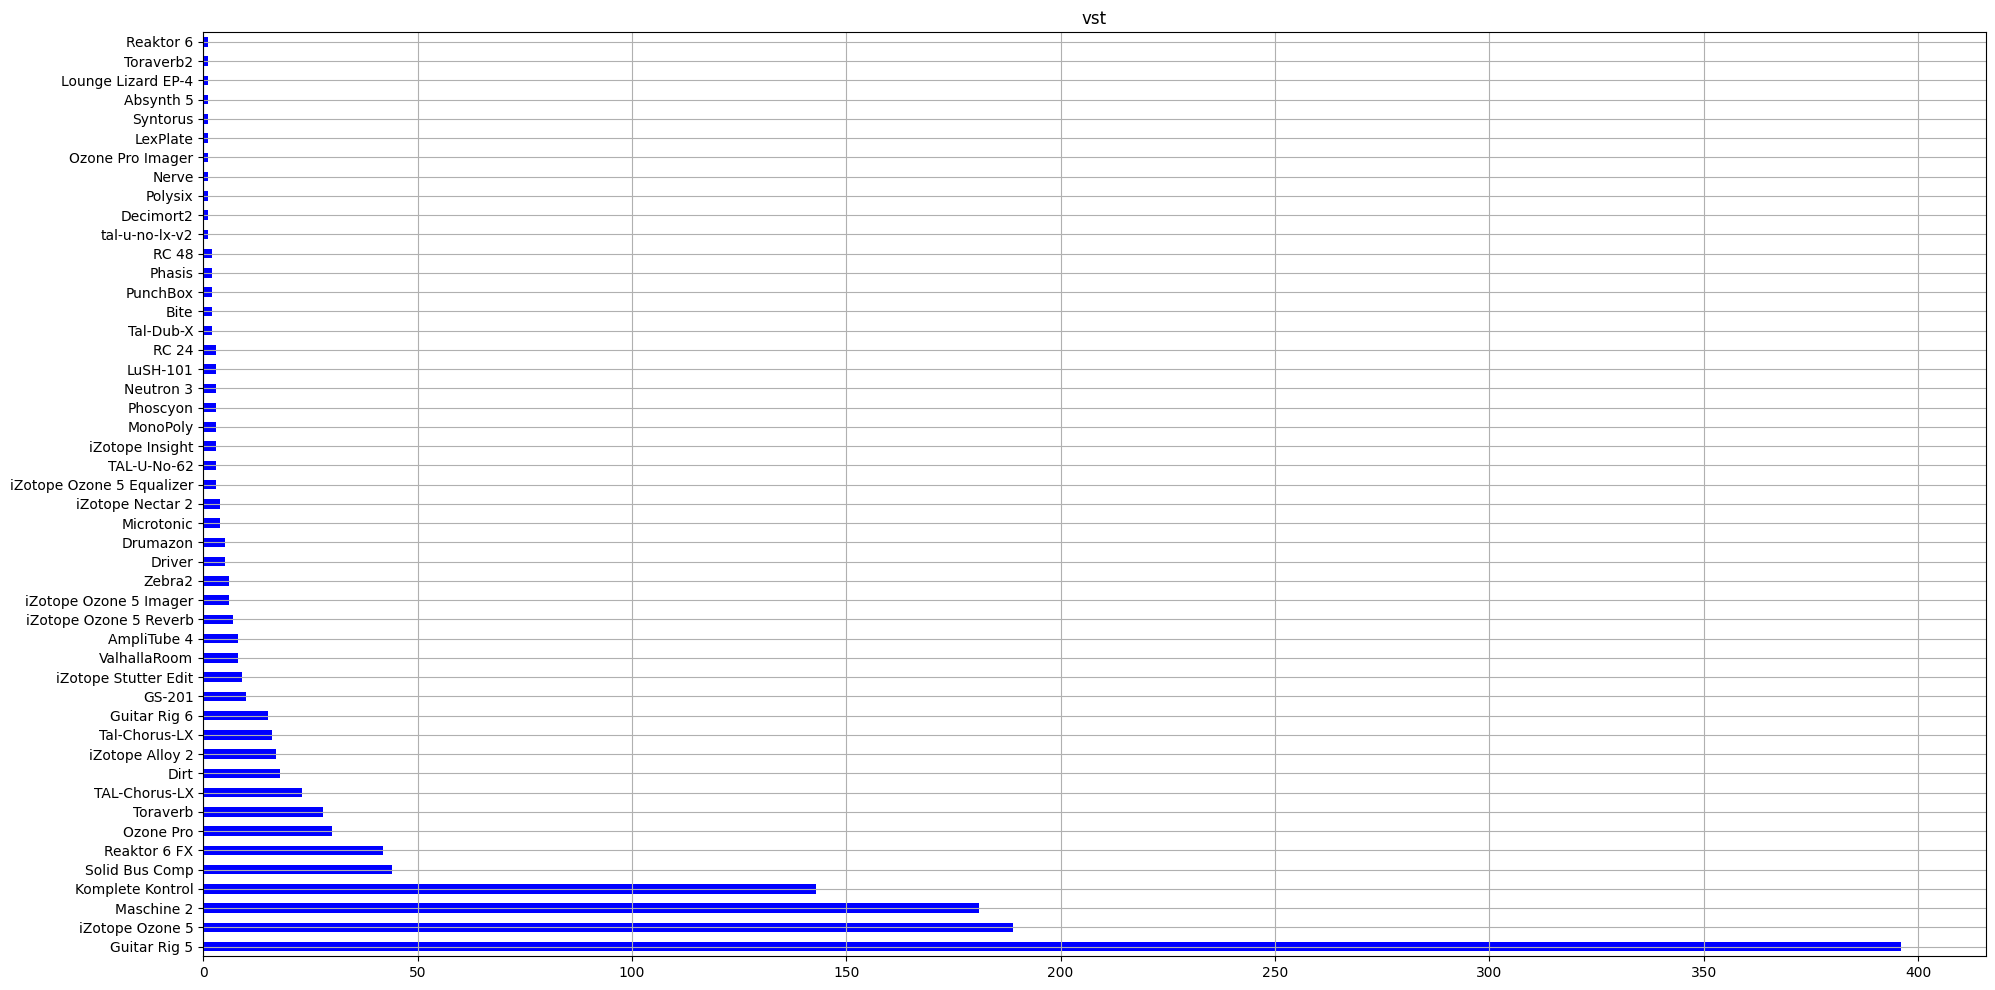

1000 least used audio_unit plugins:
GS-201              37
Neutron 4           23
Crystallizer         3
iZotope Nectar 2     3
Massive              2
Komplete Kontrol     1
Maschine 2           1
iZotope Ozone 5      1
Name: count, dtype: int64


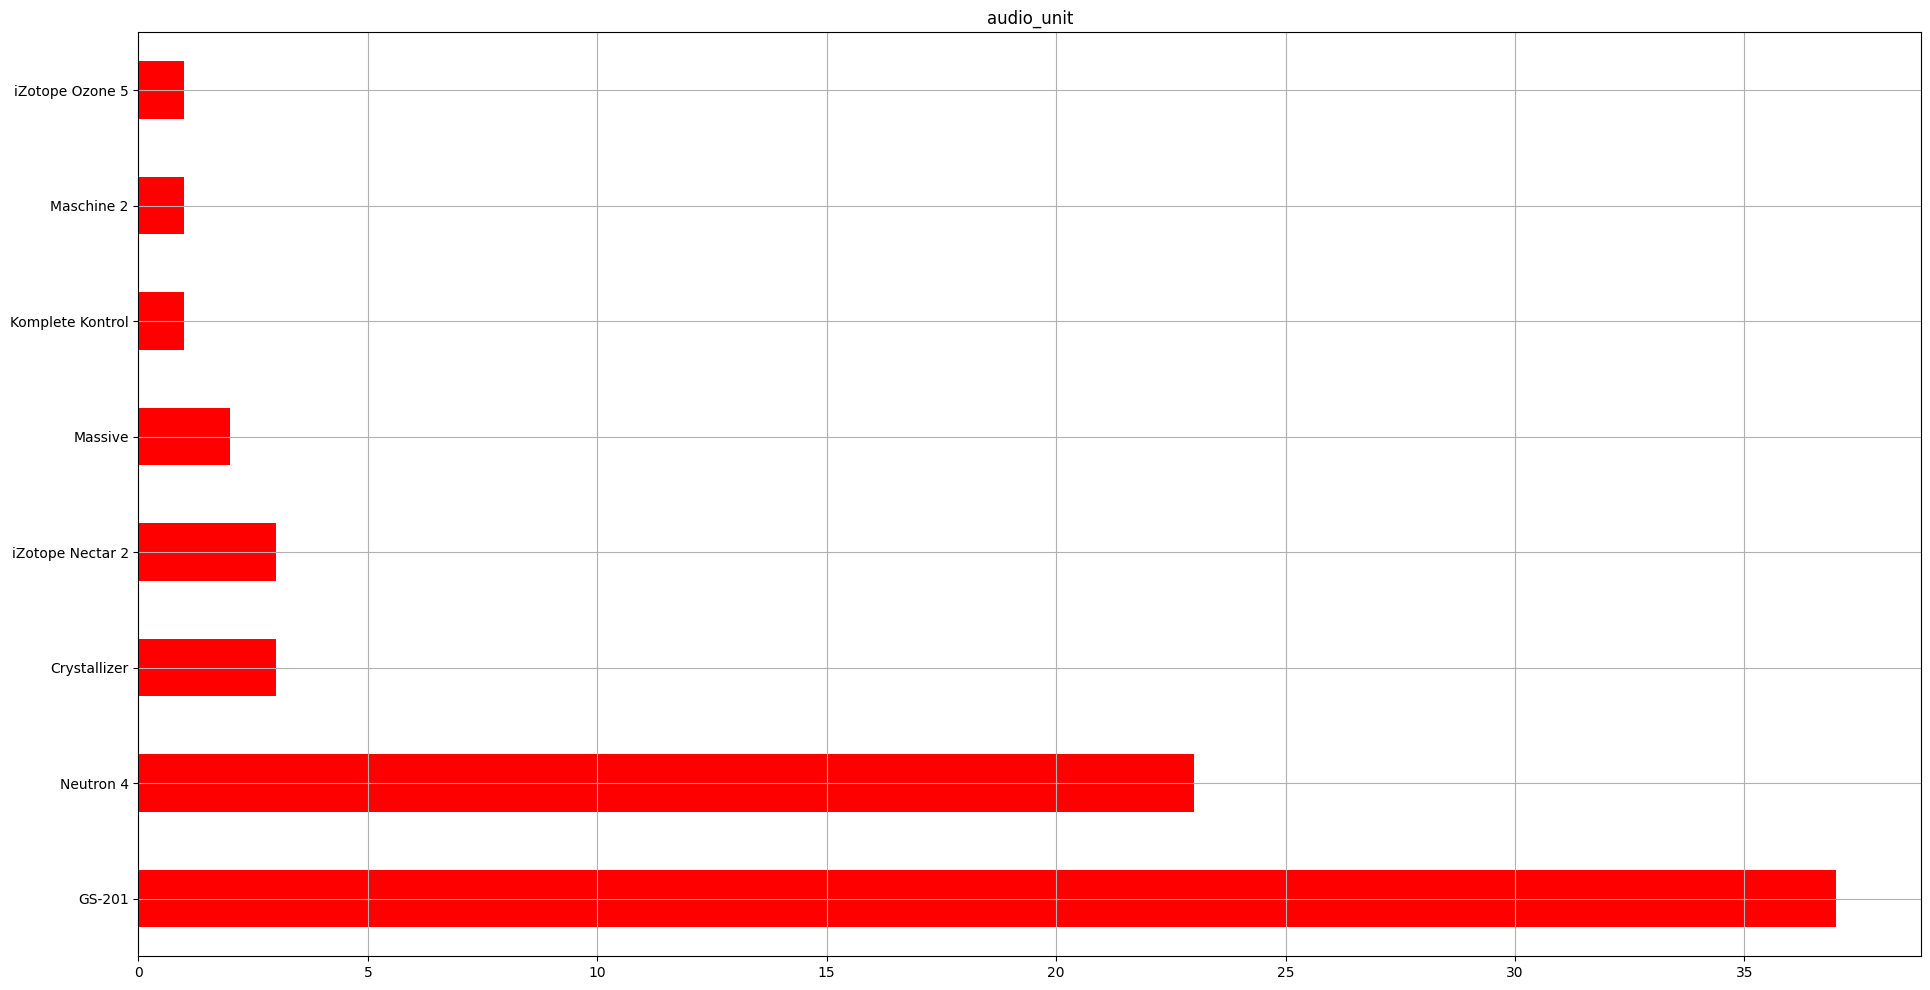

In [9]:
#@title Show VST and AU usage

# Show histogram of plugins
skip_keys = ['ableton']
colors = ['green', 'red', 'blue']
n=1000
plugins = get_plugin_usage(project_info)
for key in plugins.keys():
  if key in skip_keys:
    continue
  print('%d least used %s plugins:\n%s' % (n, key, plugins[key][-n:]))
  plugins[key].plot.barh(figsize=(23, 12), grid=True, color=colors.pop(), title=key)
  plt.show()

In [10]:
query_projects_by_plugin(project_info, "PluginDevice", "Neutron 4")

[]

In [11]:
#@title Some checks
DEPRECATED_PLUGINS = ["Ozone 8", "Ozone 6"] # "Neutron 3"
for vst in DEPRECATED_PLUGINS:
  print(f'CHECK\t| {vst} should not be an any projects', end='')
  assert 0 == len(query_projects_by_plugin(project_info, "PluginDevice", vst))
  print('...and is not')

ONLY_A10_AUDIO_UNIT = ['Crystallizer', 'GS-201']
for au in ONLY_A10_AUDIO_UNIT:
  print(f'NOTE\t| {au} is only available as a 32 bit audio unit')


CHECK	| Ozone 8 should not be an any projects...and is not
CHECK	| Ozone 6 should not be an any projects...and is not
NOTE	| Crystallizer is only available as a 32 bit audio unit
NOTE	| GS-201 is only available as a 32 bit audio unit


#### TODO: FIX Audiounit plugins
* dimensions 4: on a10, swap out iZotope Ozone 5 AU for VST
* slow burn mixdown: swap out Maschine 2 and Komplete Kontrol AU for VST
* brady-jake jam +extra day 2: swap out Massive AU for VST
* brady-jake jam 0: swap out Massive AU for VST
* acoustic sad vox (multiple): swap out iZotope Nectar 2 AU for VST

**TODO**:add above check that the only 2 audiounites are ONLY_A10_AUDIO_UNIT


In [12]:
#@title Query
plugin_type = "PluginDevice" #@param ["PluginDevice", "AuPluginDevice"]
preset_name = "Reaktor 6 FX" #@param {type:"string"}

projects = query_projects_by_plugin(project_info,
    plugin_type=plugin_type,
    preset_name=preset_name
)

print('Projects matching preset: %s\n' % preset_name)
for p in sorted(projects):
  print(p)

Projects matching preset: Reaktor 6 FX

2021 mac13 template-1
2021 mac13 template-2
MORE of a jam-10
NEW YTEMPLATE-2
a-1
a-2
aciustic mac feedback-1
aciustic mac feedback-2
acoustic jam psych-1
acoustrunkv2-2
acoustrunkv2-3
acoustrunkv2-4
acoustrunkv2-5
acoustrunkvo-1
acoustrunkvo-2
autotune sad minor guitar-3
bnchmark-1
bnchmark-2
current template-2
death flutes-6
garage rock template-3
guitar live-1
guitar vox loops downmixed-1
guitar vox loops downmixed-2
guitar vox loops-1
guitar vox loops-2
hipohopy-1
hipohopy-2
loose acousitc distorted vox loop jam-1
makings of a jam-2
new roume jaamz-1
psychccy acoust trip loops-3
sad verse psych-1
sad verse psych-2
single trackpyshch new roume accoustic blah-1
slow dark garage jaaam-3
soul sample-3
template_2020 2-1
template_2020 2-2
template_2020-1
template_2020-2
traoppy-6


In [13]:
#@title Audio Unit Query
plugin_type = "AuPluginDevice" #@param ["PluginDevice", "AuPluginDevice"]
preset_name = "GS-201" #@param {type:"string"}

projects = query_projects_by_plugin(project_info,
    plugin_type=plugin_type,
    preset_name=preset_name
)

print('Projects matching preset: %s\n' % preset_name)
for p in sorted(projects):
  print(p)

Projects matching preset: GS-201

1-27
2-14
3-7
4-22
461-6
5-14
5-15
Blazed Electric Guitar recorded-8
Dance Beat [Loops]-7
Dowm Chill 'vErB up-14
Downtime Chill Vibe-6
Green the color-8
Maggots Chill-5
SpokoACIDsampler [song] [unmxd]-10
b itch gowsays [Loops]-3
b itch gowsays [Loops]-7
dimension live remix 2-7
dimension live remix 2-9
hazzy chill-7
high vox loops-2
high vox loops-3
high vox loops-5
high vox loops-7
jarryork 23-5
jarryork-5
loaunge chill j a10 gsi-8
lofi accoustic psych-7
new bumpabumb-15
psych guiTarr beat-2
psych guiTarr beat-4
something-7
surff classicaL sh-3
trippy vox loops-2
trippy vox loops-3
trippy vox loops-5
trippy vox loops-7
watching fish-11
